# NEP5 – porteføljeanalyse

Hvor kommer fondens afkast fra, hvad koster det i risiko, og hvor sikkert er det? Analysen er
**fondsniveau**: hele fondens beholdninger, brutto for honorar og carry, fra
`rpt.v_portfolio_holding` - ikke vores andel.

Al logik ligger i `pe_analysis/portefoelje/`; notebooken vælger fonden og kalder én metode pr.
slide. Hver metode gemmer en PNG i `charts/`, og de sidste celler skriver Excel og PowerPoint
til `exports/`.

> Hvilke slides der tegnes, afgøres af fondens data. En metode, der mangler det, den skal bruge
> (IRR pr. handel, exit-datoer, instrumenttype ...), skriver hvorfor og springer over.

In [1]:
from pe_analysis.portefoelje import Portefoelje

## Konfiguration

In [2]:
FUND_CODE = "NEP5"
AS_OF     = None      # None = seneste fondsrapport; ellers fx "2025-12-31"

## Indlæsning og afstemning

Beholdningerne beriges (ét navn pr. selskab, instrumenttype, gruppe, vintage) og afstemmes: hver
dimension skal summere til rapportens totaler, og positionerne til fondens egen ændring.

In [3]:
pf = Portefoelje(FUND_CODE, as_of=AS_OF)

NEP5: Newbury Equity Partners V · pr. 30.06.2026 · 25 rapportdatoer (30.06.2020 →) · 129 fonde / 139 linjer
  Investeret $1.772,1m | udlodninger $571,0m | dagsværdi $1.906,2m | TVPI 1,40x = DPI 0,32x + RVPI 1,08x
  Datagrundlag: investeringstype ja, instrument nej, IRR pr. handel nej, realiseret/urealiseret ja, exit-dato nej, vintage ja, handelsvaluta nej, flere datoer ja
  Seneste kvartal 31.03.2026 → 30.06.2026: −$25,1m merværdi · år til dato fra 31.12.2025: −$39,7m · 142 positioner, 2 nye, 3 udgåede


  Periodeafkast (Modified Dietz): kvartalet −1,34 % · år til dato −1,92 % · 4 restaterede positioner udeladt af de relative tal


# 1. Overblik og værdibro

Hvor står fonden, og hvor meget af værdien er kasse? TVPI alene siger ikke, om afkastet er tjent hjem eller lovet.

In [4]:
pf.graf_noegletal()

gemt: charts\nep5_portefoelje_noegletal.png  (3200 x 1800 px · 16:9)


<Figure size 1466.67x825 with 0 Axes>

gemt: charts\nep5_portefoelje_vaerdibro.png  (3200 x 1800 px · 16:9)


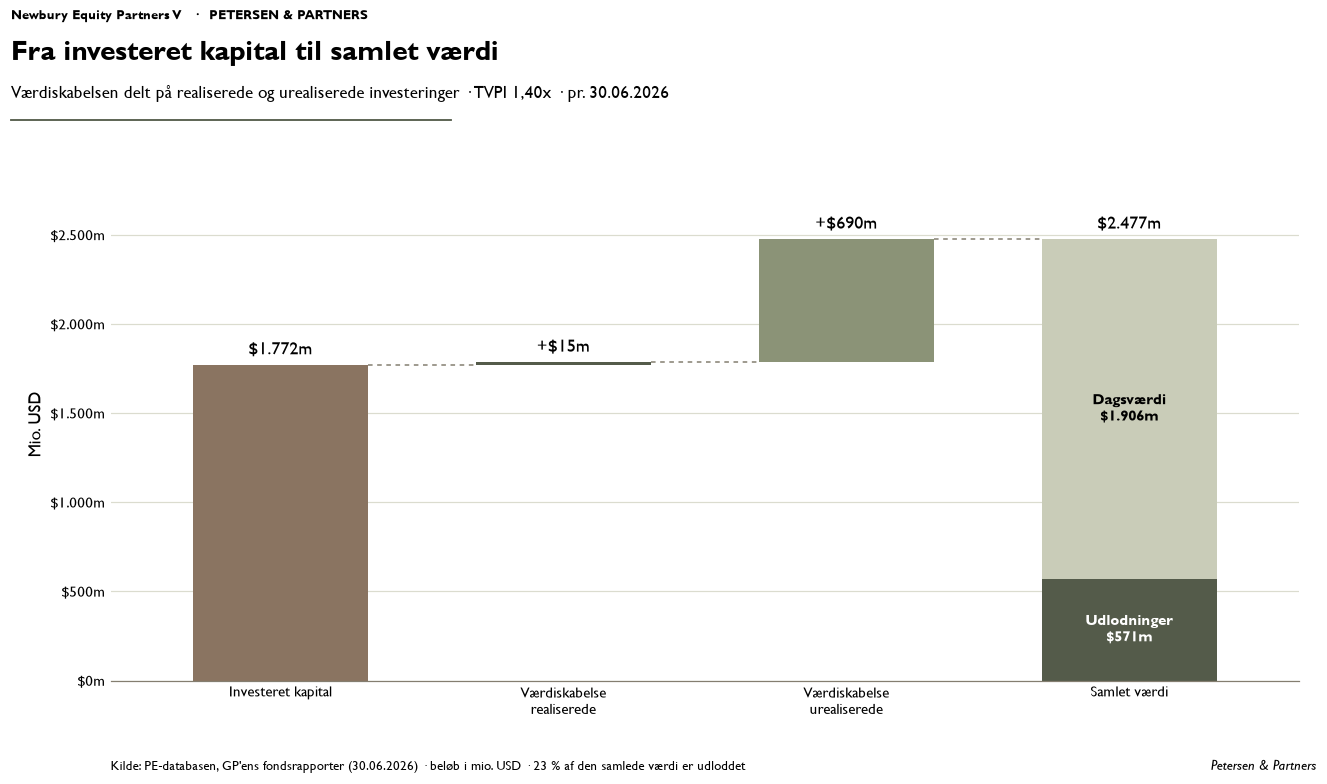

In [5]:
pf.graf_vaerdibro()

gemt: charts\nep5_portefoelje_boeger.png  (3200 x 1800 px · 16:9)


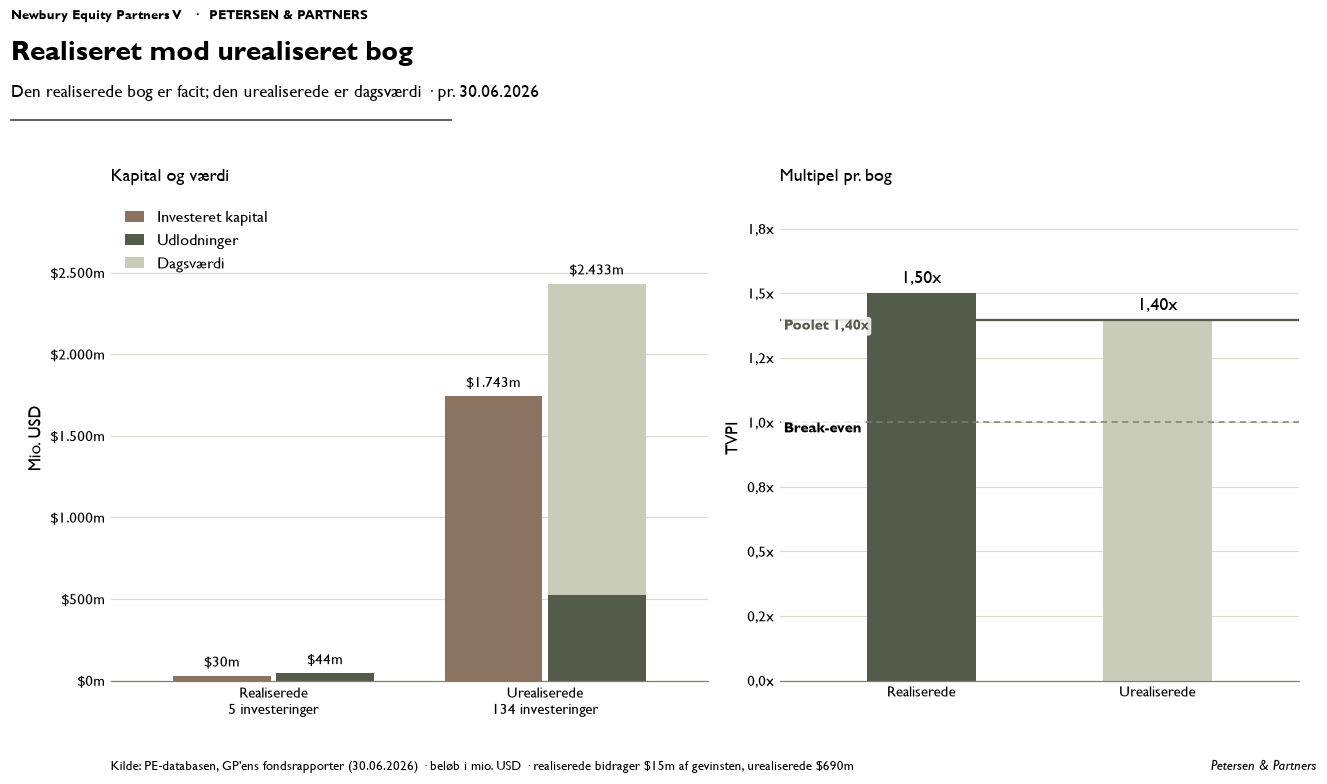

In [6]:
pf.graf_boeger()

gemt: charts\nep5_portefoelje_tidsserie.png  (3200 x 1800 px · 16:9)


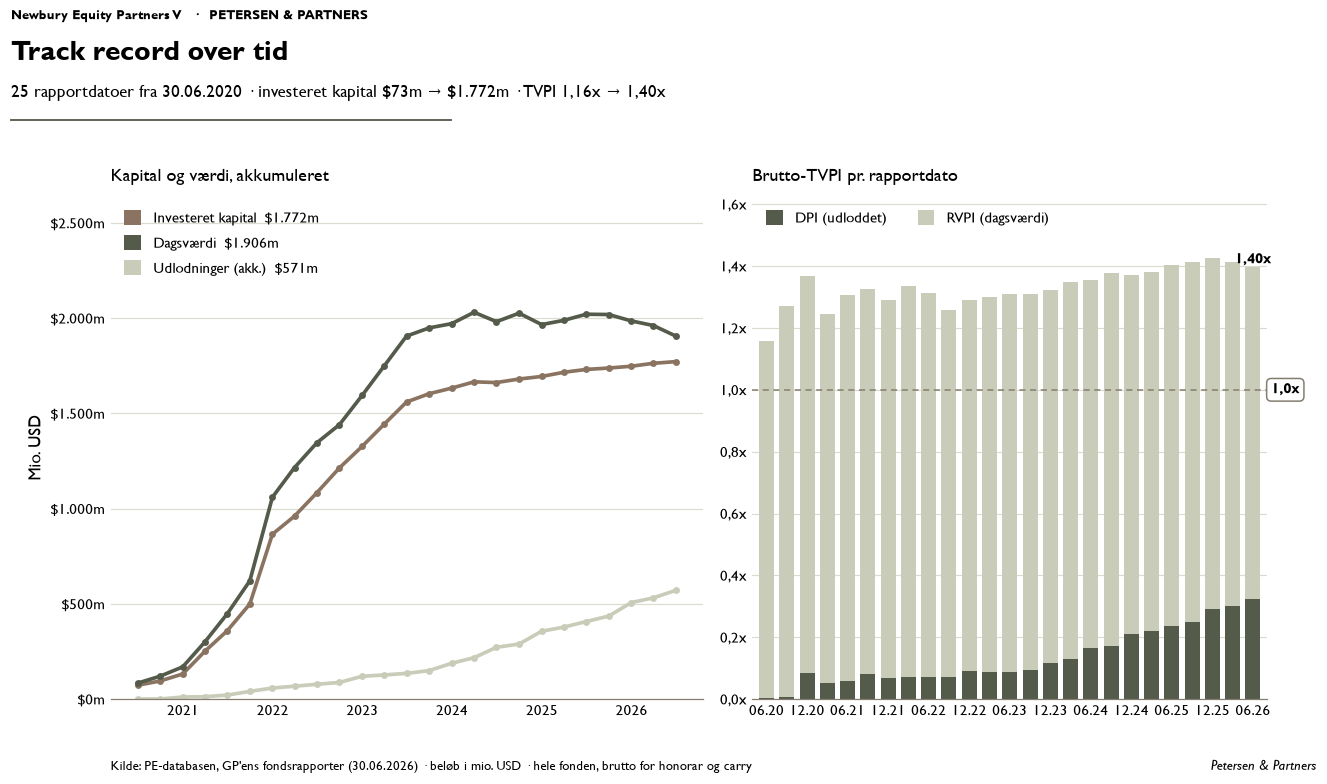

In [7]:
pf.graf_tidsserie()

# 2. Struktur

Hvad består porteføljen af, og hvad betaler de enkelte dele sig i? For PSCP er det kapitalstrukturen (instrumenttype og kapitalgruppe), for NEP investeringstypen.

gemt: charts\nep5_portefoelje_gruppemix.png  (3200 x 1800 px · 16:9)


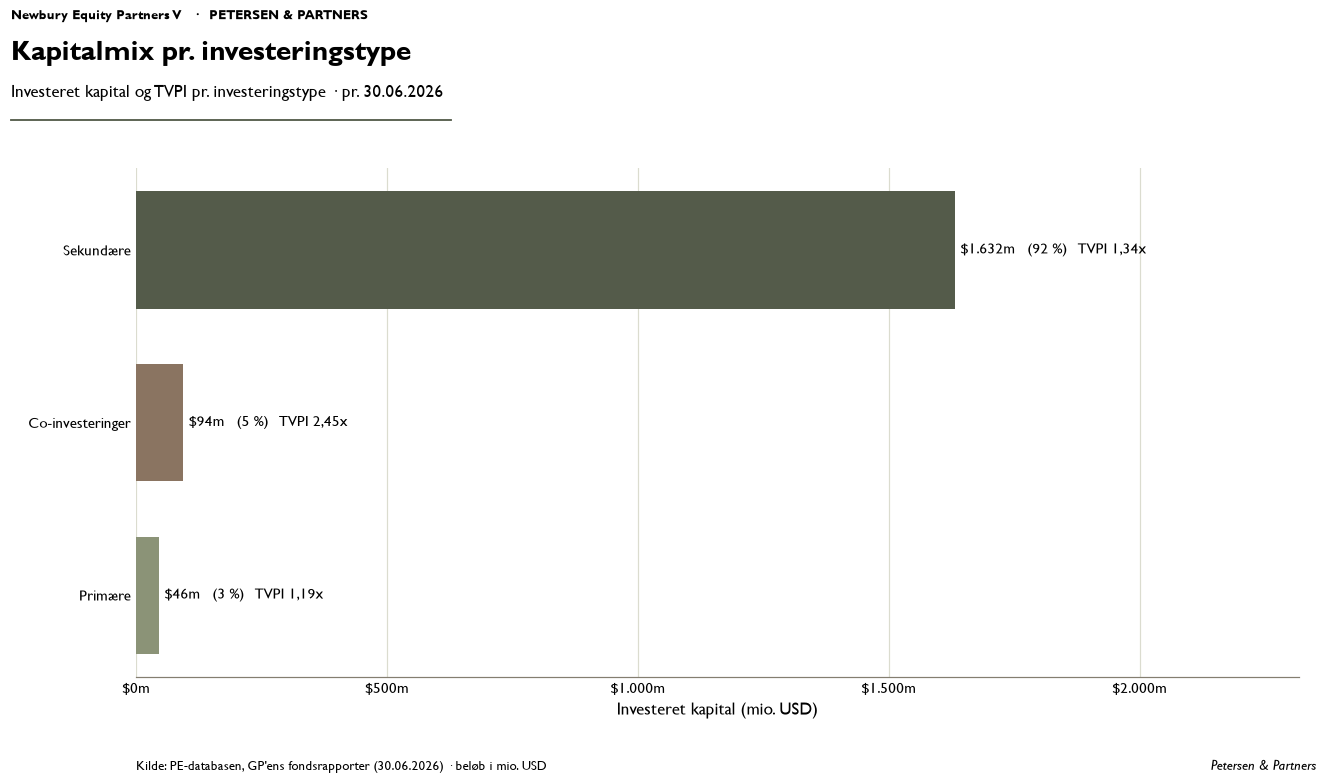

In [8]:
pf.graf_gruppemix()

gemt: charts\nep5_portefoelje_gruppe_tvpi.png  (3200 x 1800 px · 16:9)


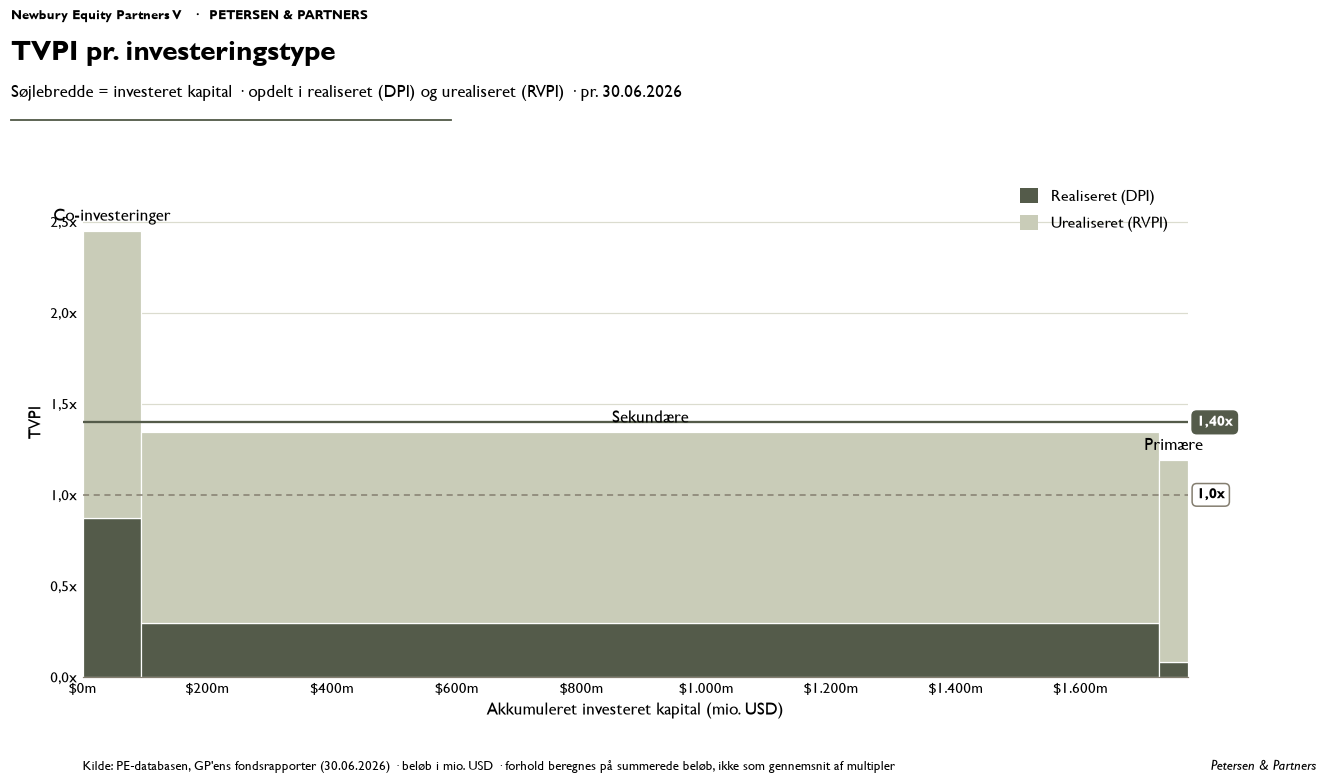

In [9]:
pf.graf_gruppe_tvpi()

gemt: charts\nep5_portefoelje_kapitalgruppe.png  (3200 x 1800 px · 16:9)


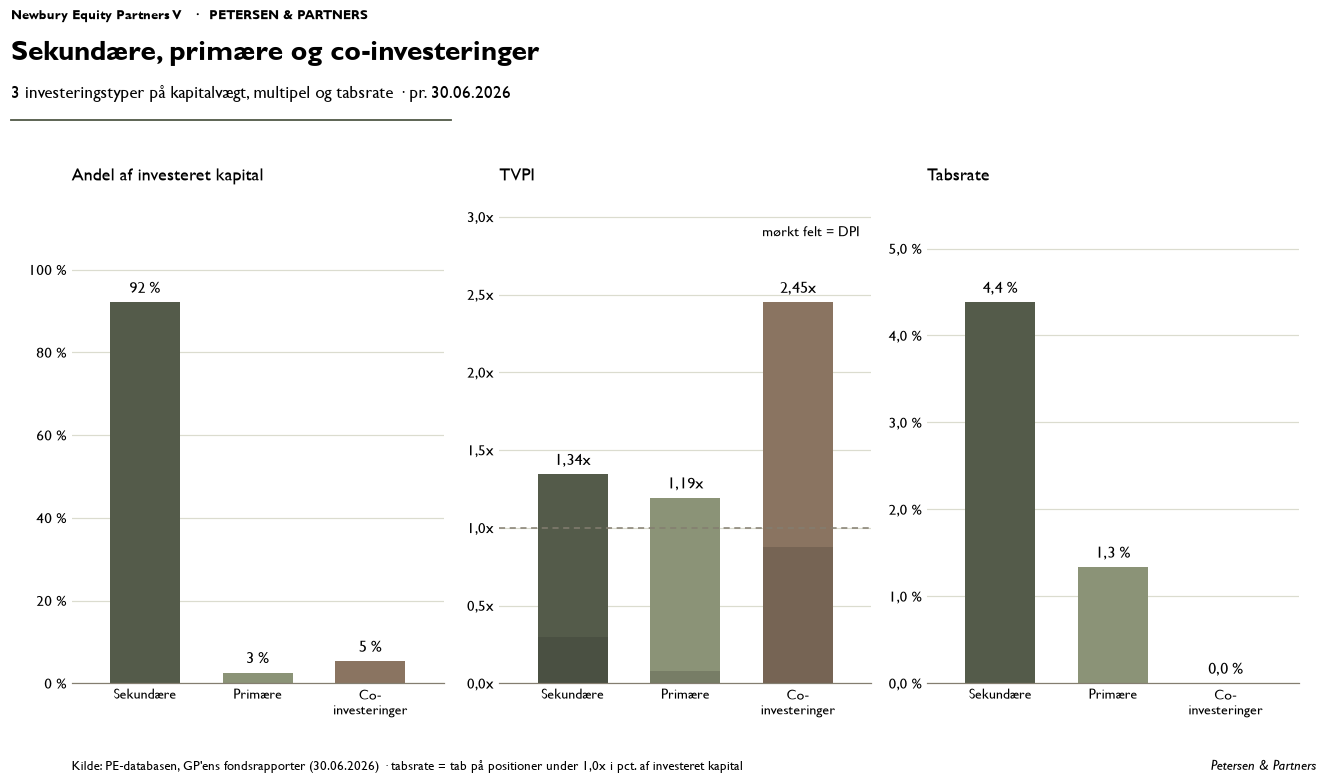

In [10]:
pf.graf_kapitalgruppe()

gemt: charts\nep5_portefoelje_gruppemix_tid.png  (3200 x 1800 px · 16:9)


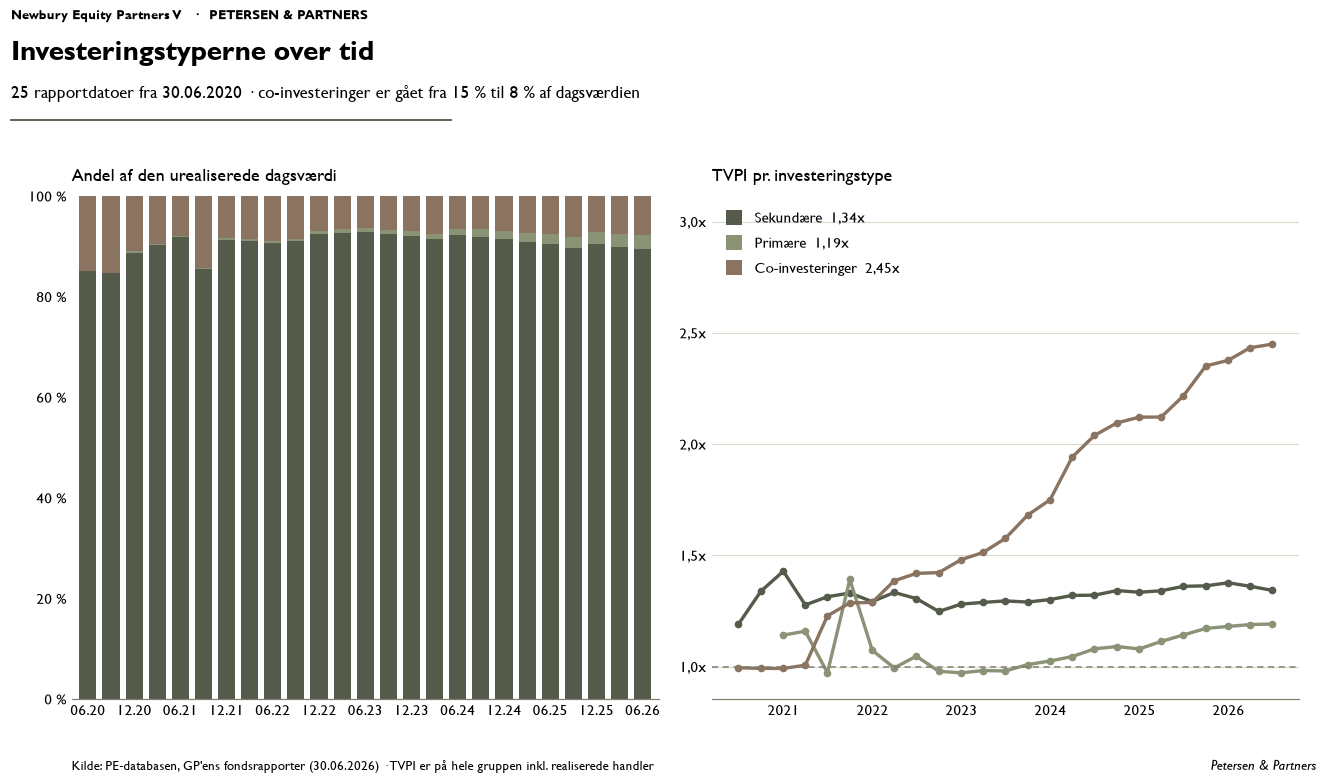

In [11]:
pf.graf_gruppemix_tid()

# 3. Afkastspredning, tab og koncentration

En poolet multipel kan dække over en jævn portefølje eller nogle få store gevinster oven på en stribe tab.

gemt: charts\nep5_portefoelje_spredning.png  (3200 x 1800 px · 16:9)


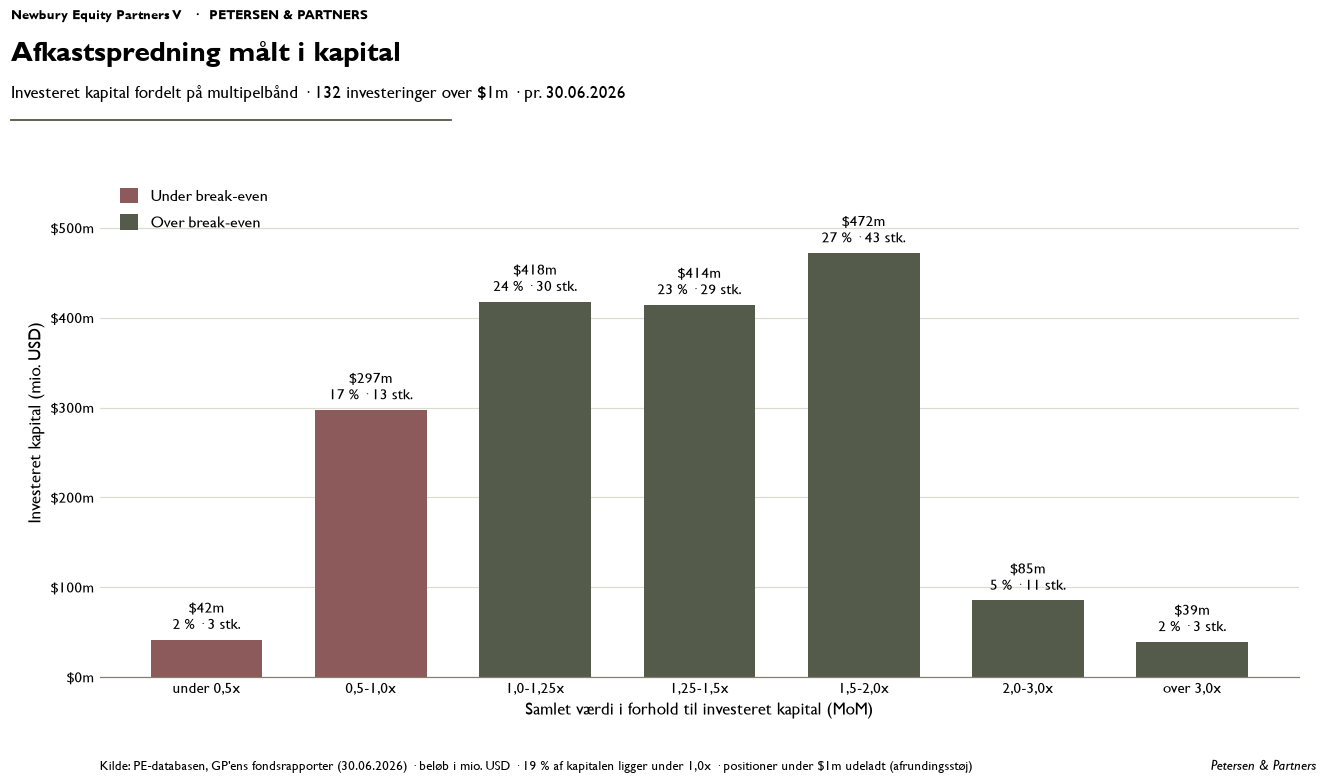

In [12]:
pf.graf_spredning()

gemt: charts\nep5_portefoelje_tabsanalyse.png  (3200 x 1800 px · 16:9)


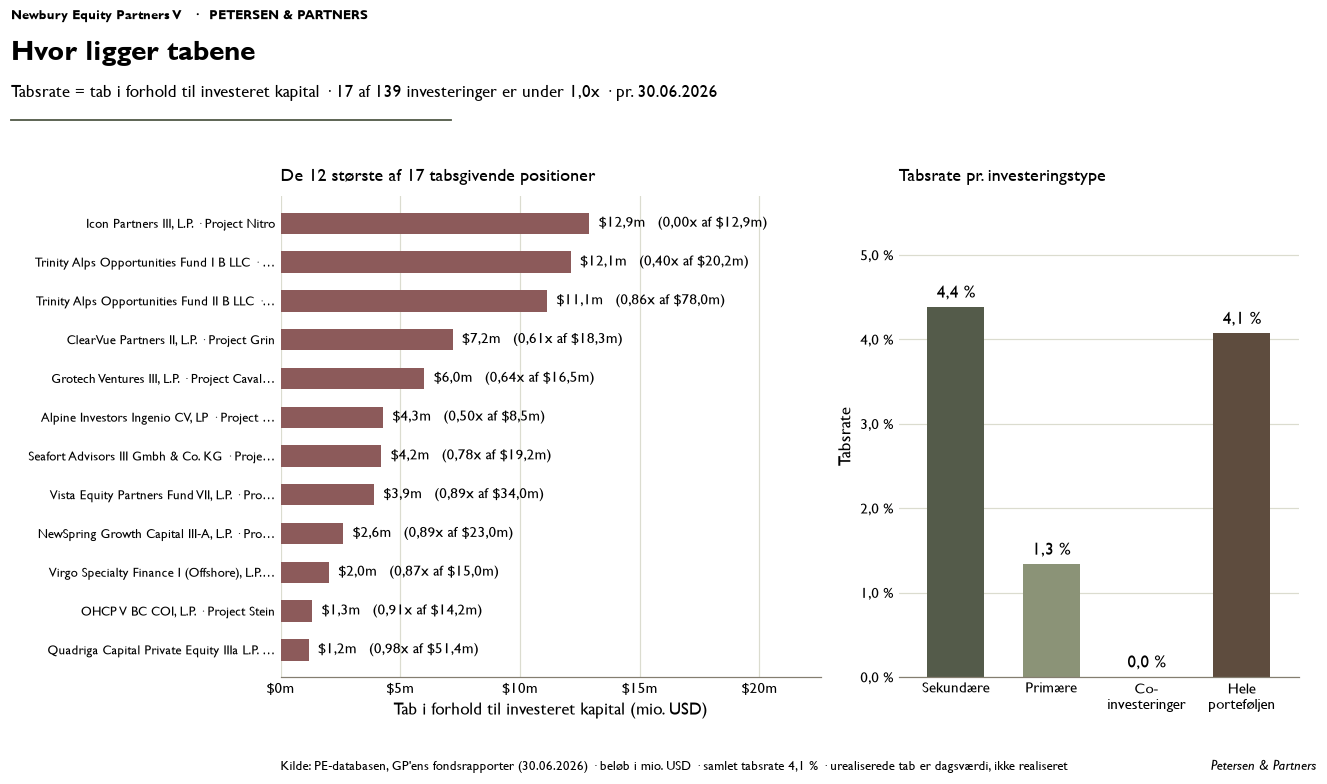

In [13]:
pf.graf_tabsanalyse()

gemt: charts\nep5_portefoelje_nedskrivning.png  (3200 x 1800 px · 16:9)


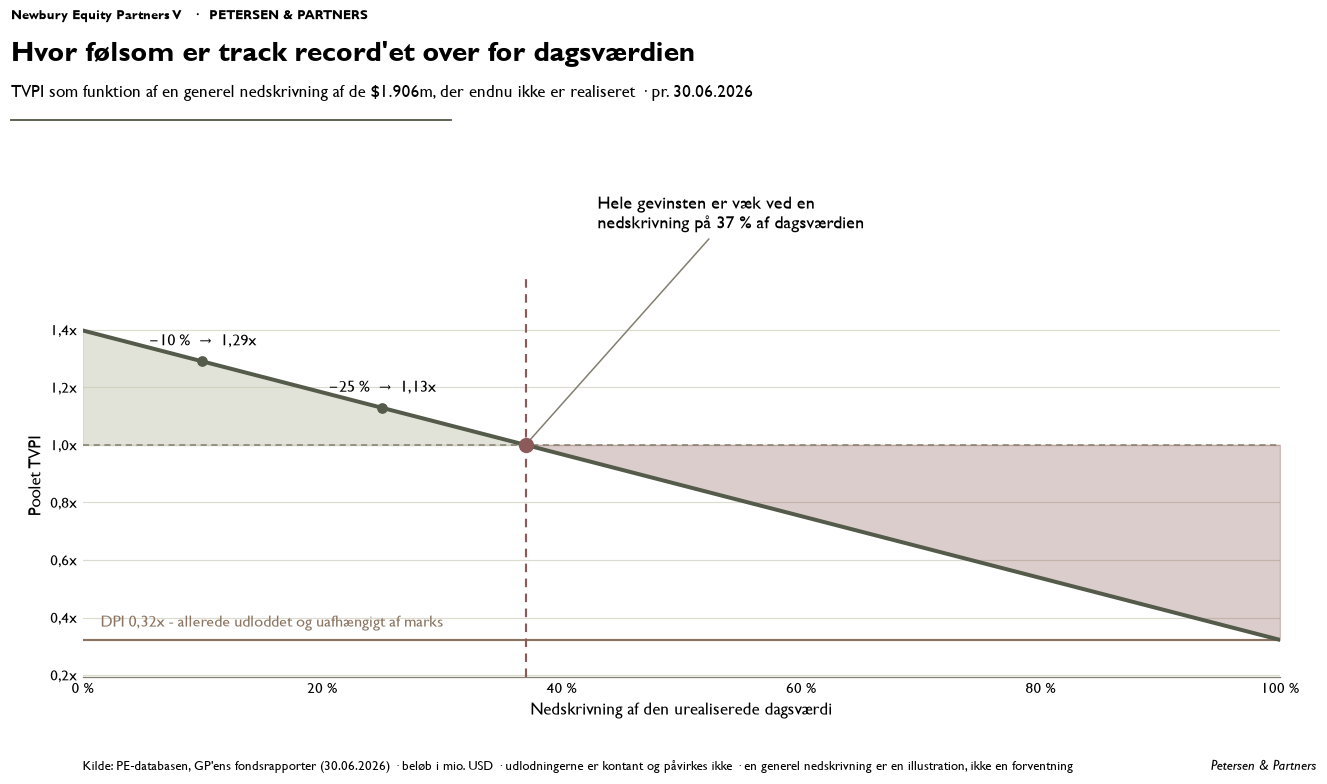

In [14]:
pf.graf_nedskrivning()

gemt: charts\nep5_portefoelje_koncentration.png  (3200 x 1800 px · 16:9)


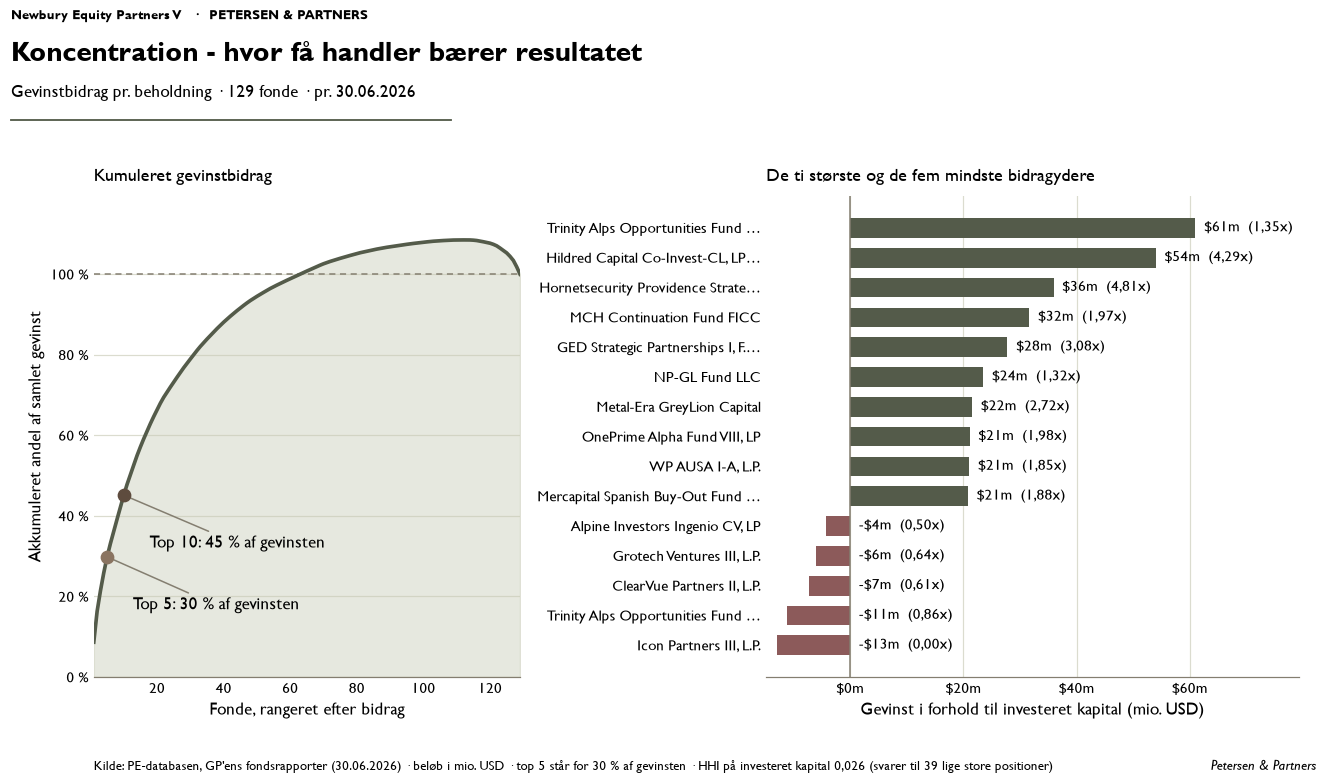

In [15]:
pf.graf_koncentration()

# 4. Afkast mod tid

Multipel og IRR belønner to forskellige ting. Periodeafkastet (Modified Dietz) er det eneste sted, der findes et procentafkast for en periode.

In [16]:
pf.graf_irr_vs_mom()

Ingen IRR pr. handel for NEP5 - springer over


In [17]:
pf.graf_irr_fordeling()

Ingen IRR pr. handel for NEP5 - springer over


In [18]:
pf.graf_holdeperiode()

Ingen exit-datoer for NEP5 - springer over


gemt: charts\nep5_portefoelje_periodeafkast.png  (3200 x 1800 px · 16:9)


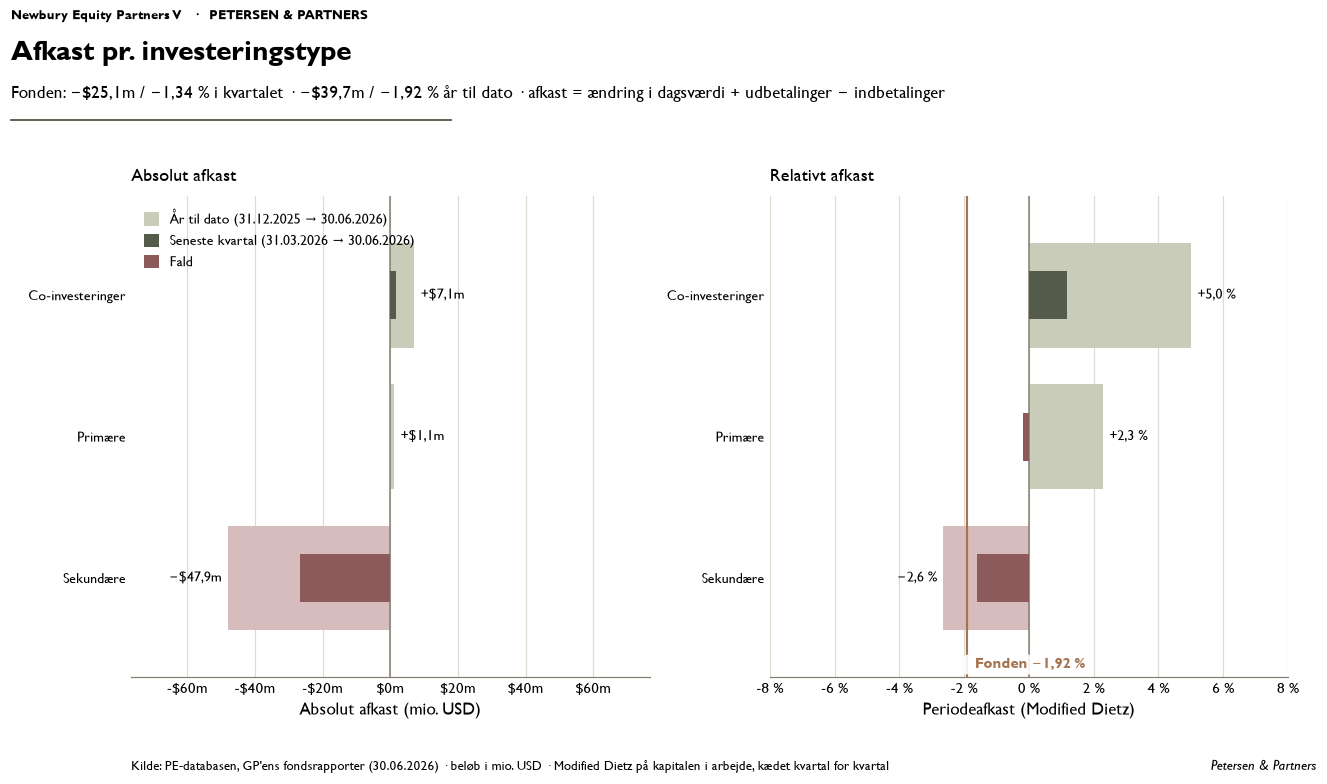

In [19]:
pf.graf_periodeafkast()

In [20]:
pf.graf_delboeger()

Ingen delbøger defineret for fonden for NEP5 - springer over


# 5. Vintage og realiseringstakt

Hvornår blev kapitalen sat i arbejde, og hvor moden er hver årgang?

gemt: charts\nep5_portefoelje_vintage_kapital.png  (3200 x 1800 px · 16:9)


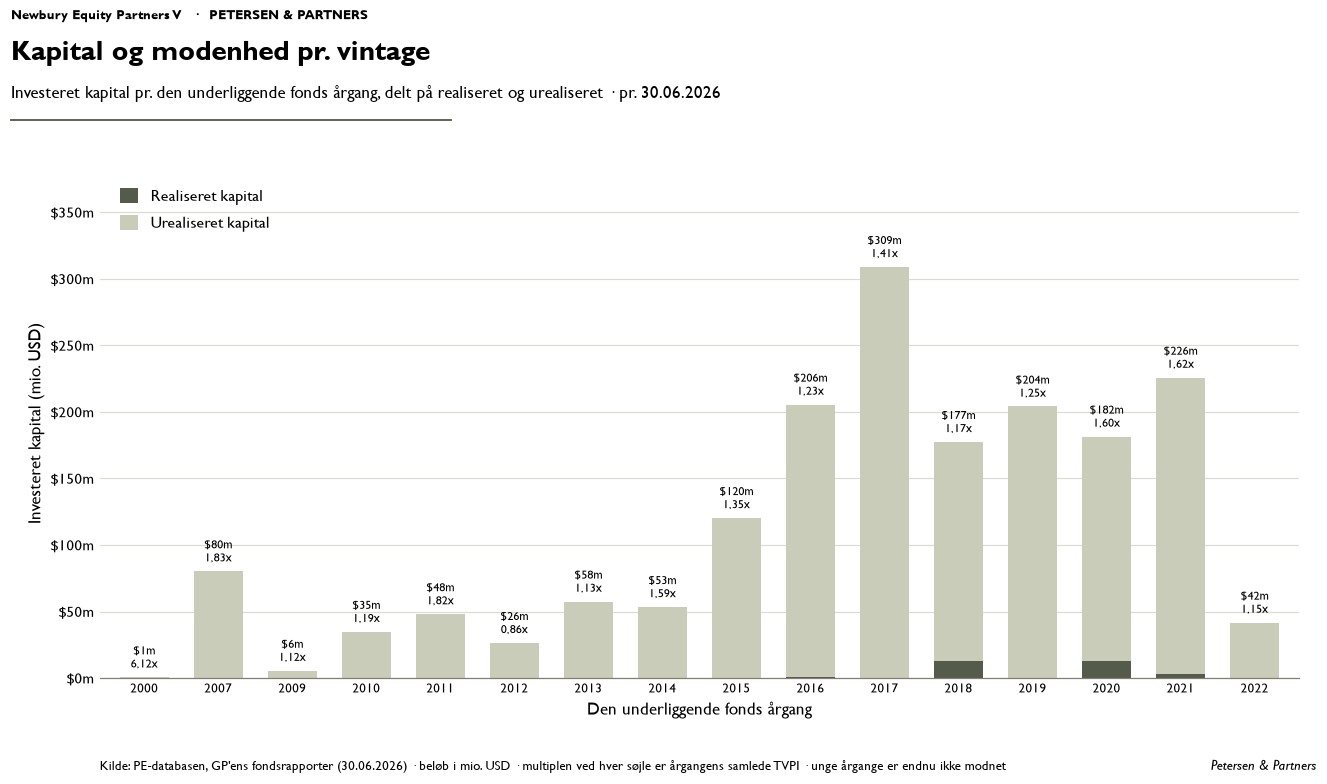

In [21]:
pf.graf_vintage_kapital()

gemt: charts\nep5_portefoelje_vintage_tvpi.png  (3200 x 1800 px · 16:9)


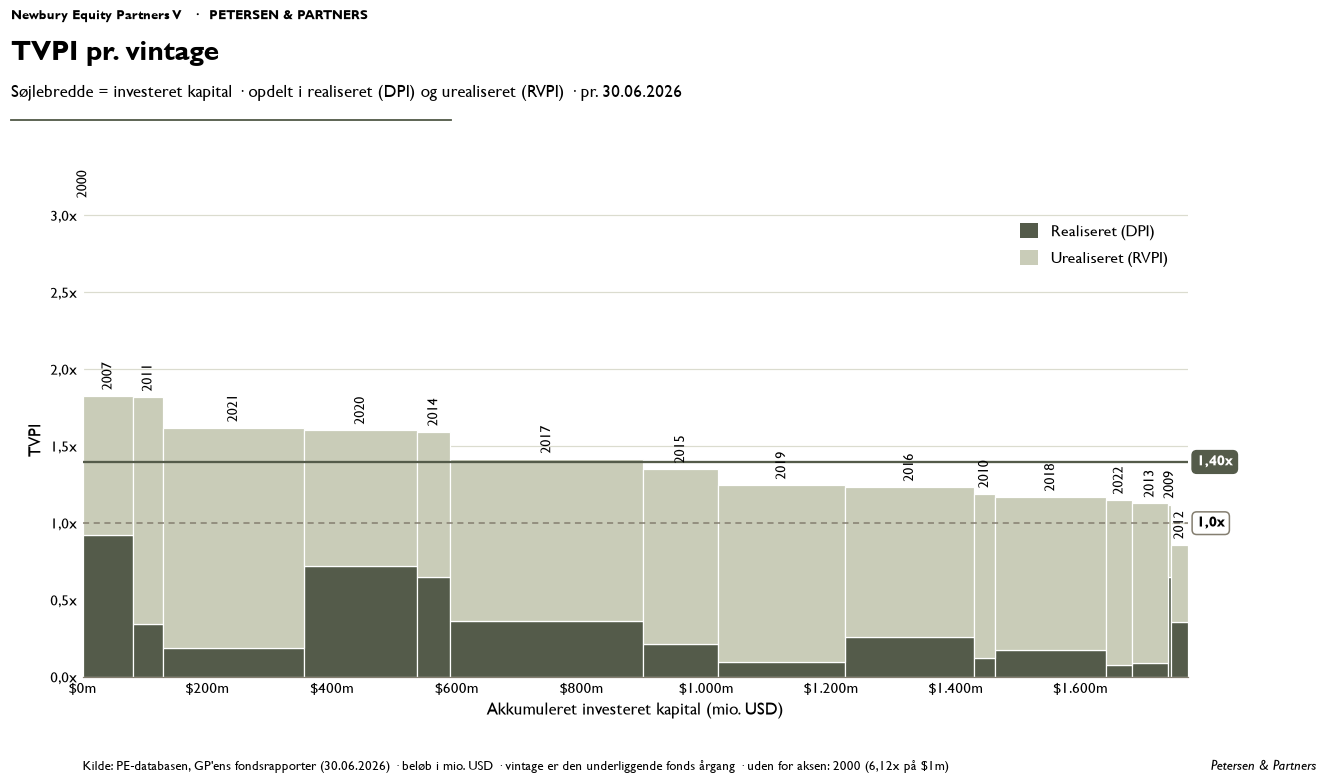

In [22]:
pf.graf_vintage_tvpi()

In [23]:
pf.graf_exits()

Ingen exit-datoer for NEP5 - springer over


# 6. Porteføljen i dag

De urealiserede positioner er den del af track record'et, der endnu ikke er afgjort - og den hviler på GP'ens egne dagsværdier.

gemt: charts\nep5_portefoelje_urealiseret_top.png  (3200 x 1800 px · 16:9)


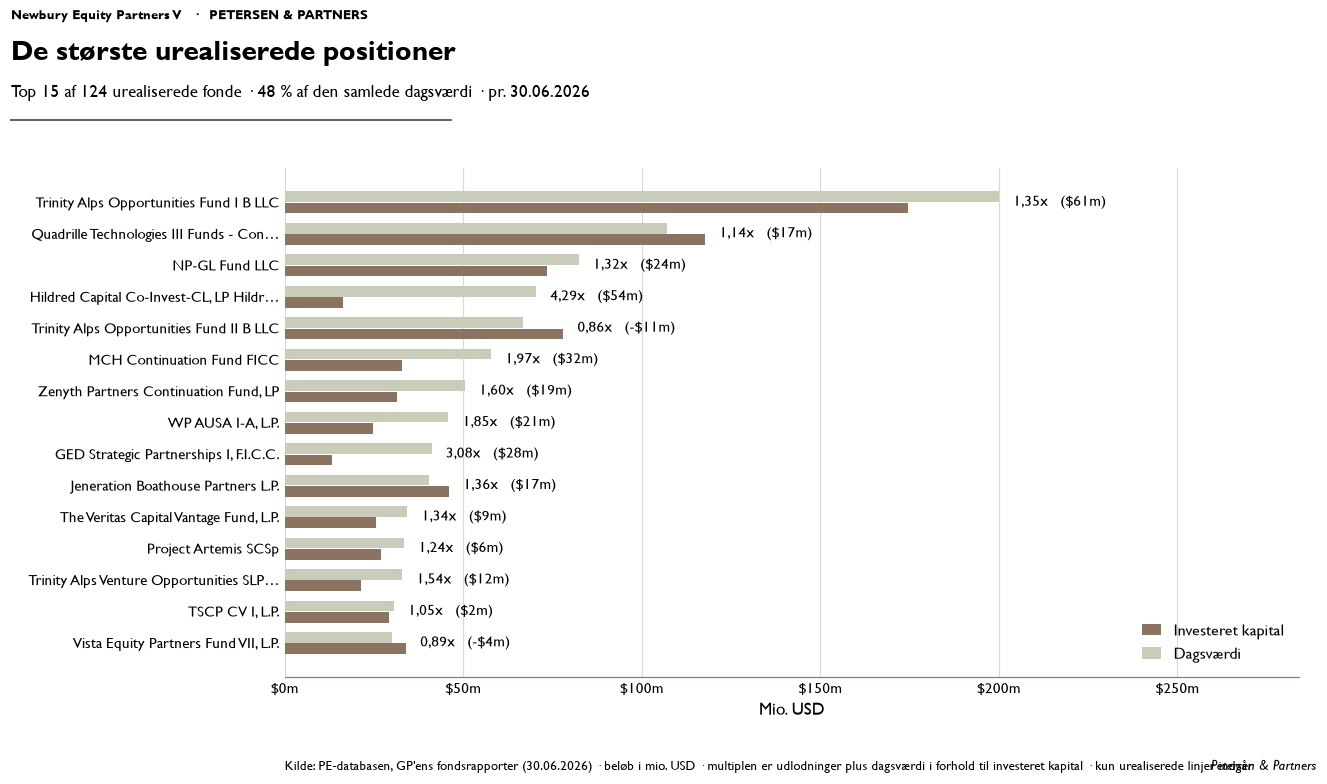

In [24]:
pf.graf_urealiseret_top()

In [25]:
pf.graf_valuta()

Ingen handelsvaluta pr. linje for NEP5 - springer over


gemt: charts\nep5_portefoelje_kvartal.png  (3200 x 1800 px · 16:9)


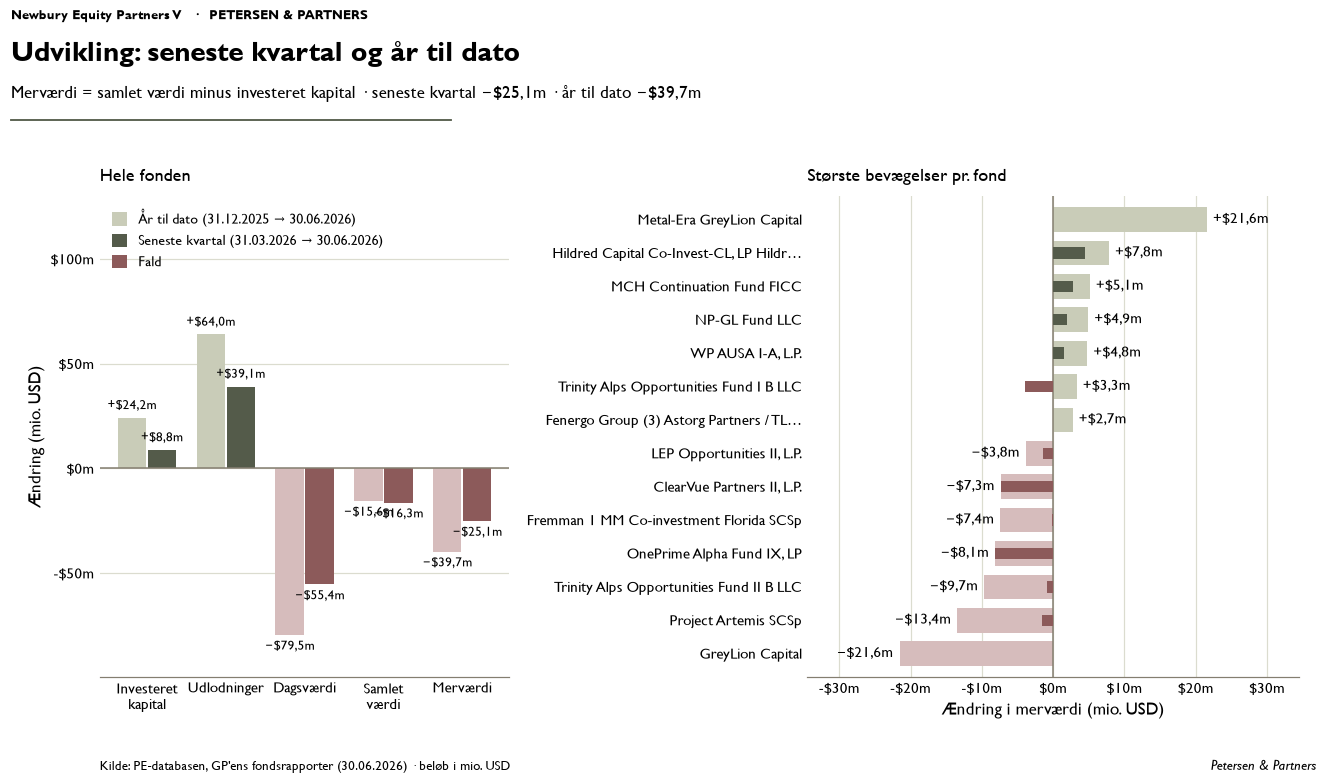

In [26]:
pf.graf_kvartal()

gemt: charts\nep5_portefoelje_positioner.png  (3200 x 1800 px · 16:9)


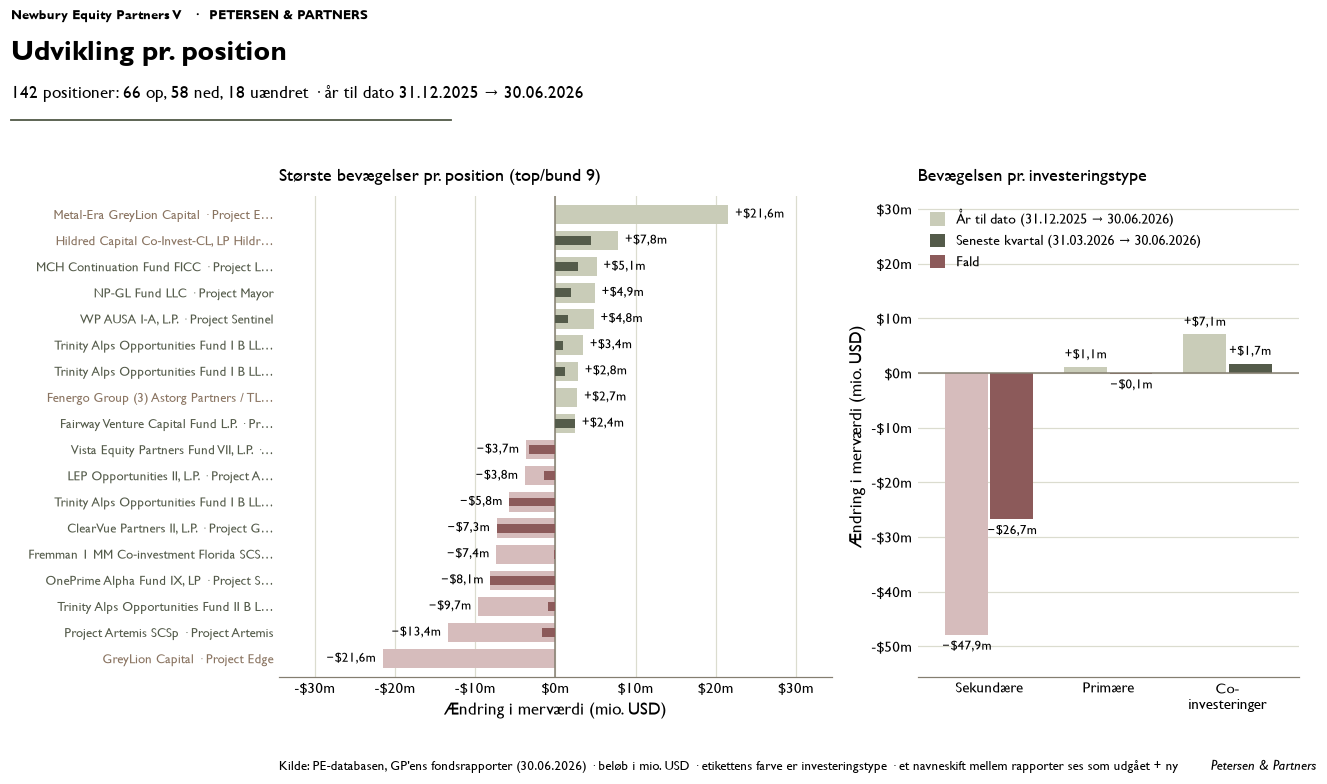

In [27]:
pf.graf_positioner()

gemt: charts\nep5_portefoelje_ureal_struktur.png  (3200 x 1800 px · 16:9)


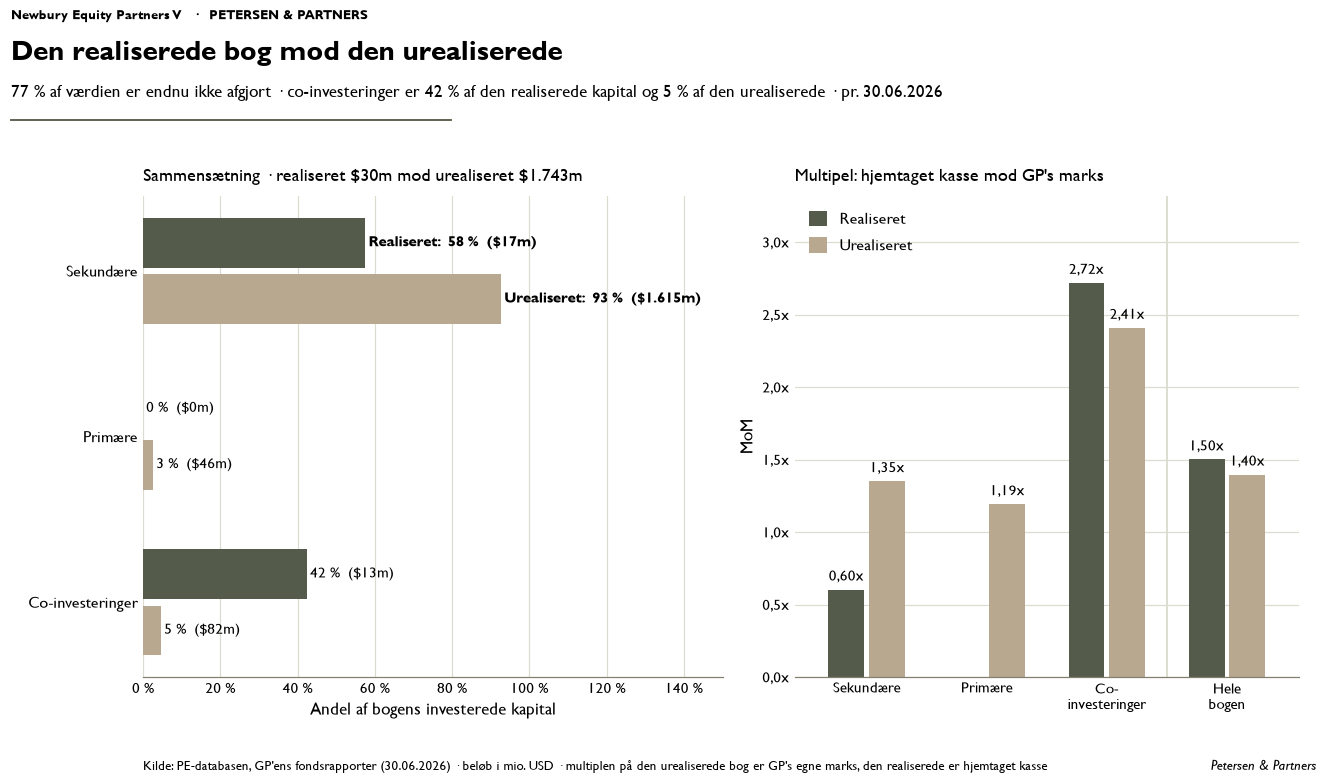

In [28]:
pf.graf_ureal_struktur()

gemt: charts\nep5_portefoelje_ureal_marks.png  (3200 x 1800 px · 16:9)


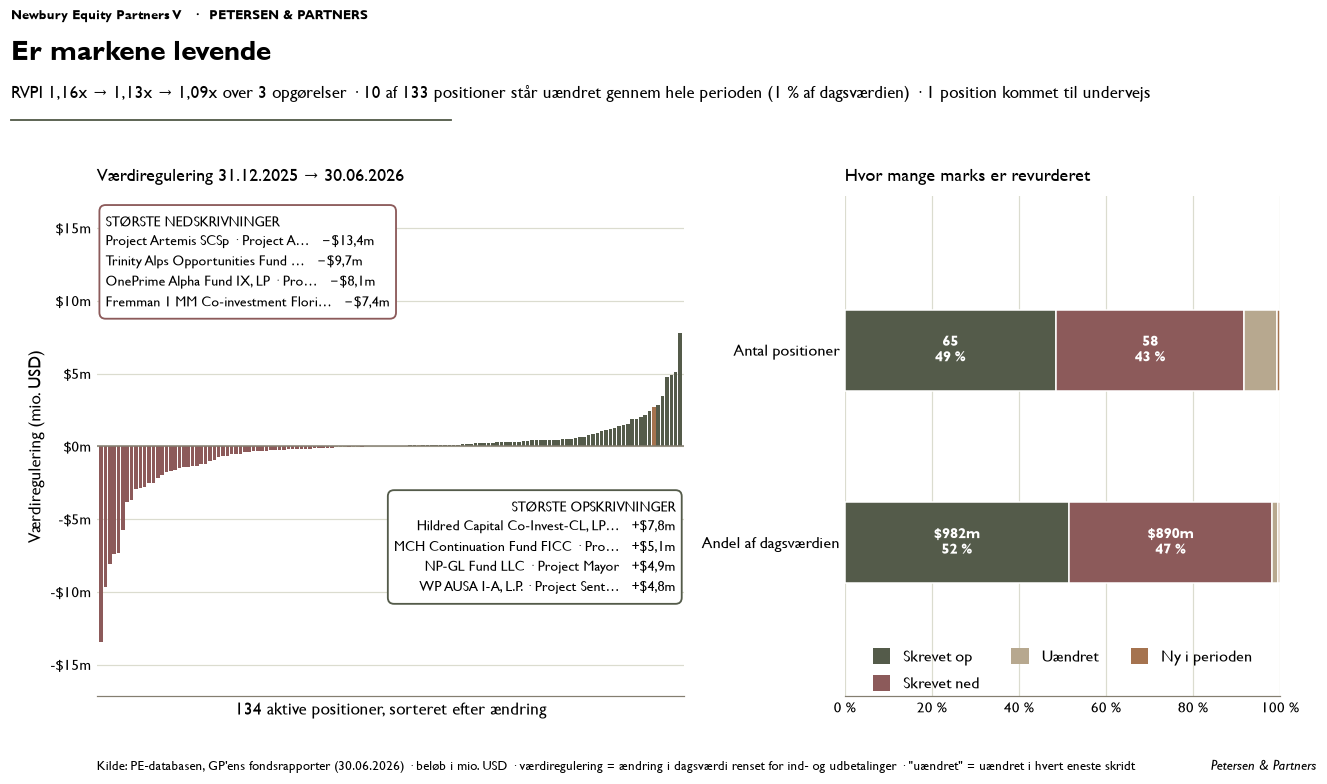

In [29]:
pf.graf_ureal_marks()

In [30]:
pf.graf_ureal_modenhed()

Ingen handelsdato pr. linje for NEP5 - springer over


gemt: charts\nep5_portefoelje_ureal_kostpris.png  (3200 x 1800 px · 16:9)


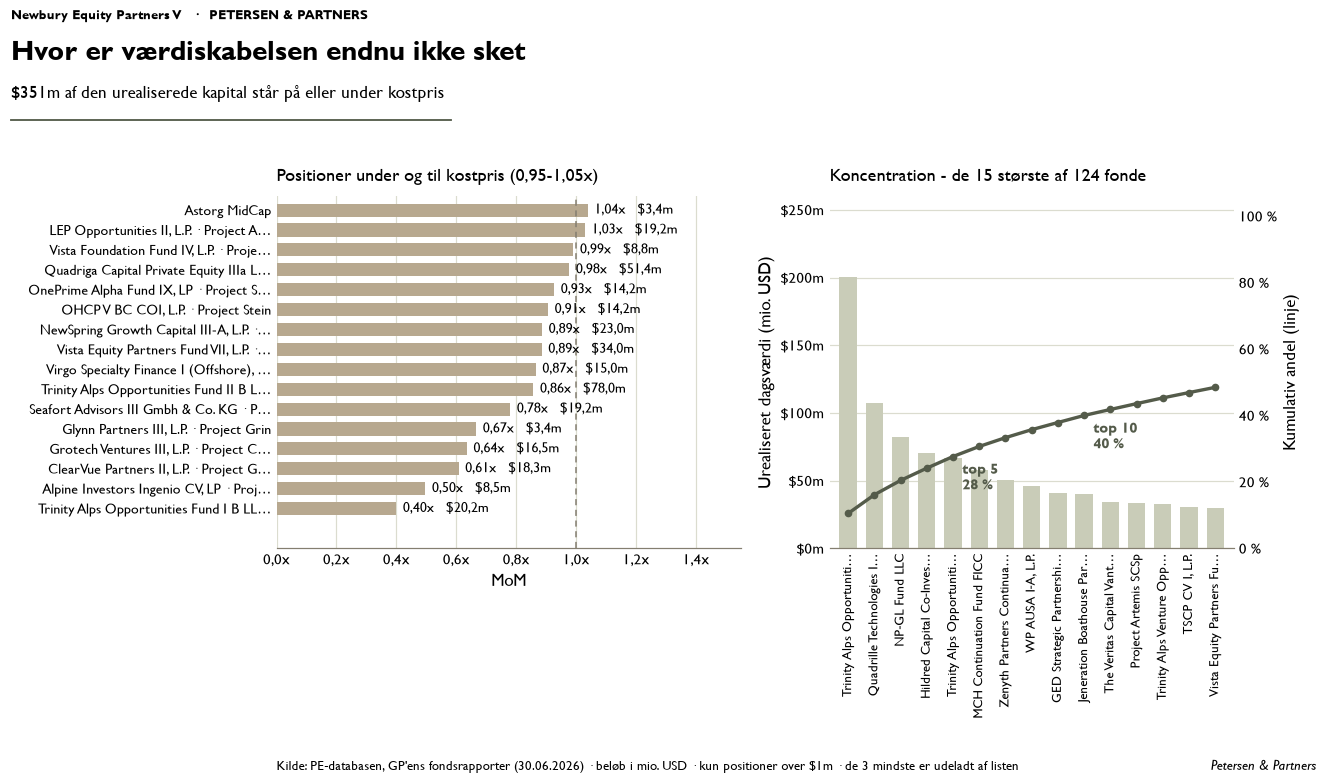

In [31]:
pf.graf_ureal_kostpris()

In [32]:
pf.graf_branche_geografi()

Ingen fordelinger på branche eller geografi fra GP'en for NEP5 - springer over


In [33]:
pf.graf_branche_tid()

Ingen fordeling med historik på mindst fire rapportdatoer for NEP5 - springer over


In [34]:
pf.graf_selskabs_kpi()

Ingen selskabsnøgletal (gearing, EBITDA, EV) for NEP5 - springer over


# 7. Nøgletal i tabelform

De samme tal som graferne, men til at læse i.

gemt: charts\nep5_portefoelje_tabel_noegletal.png  (3200 x 1800 px · 16:9)


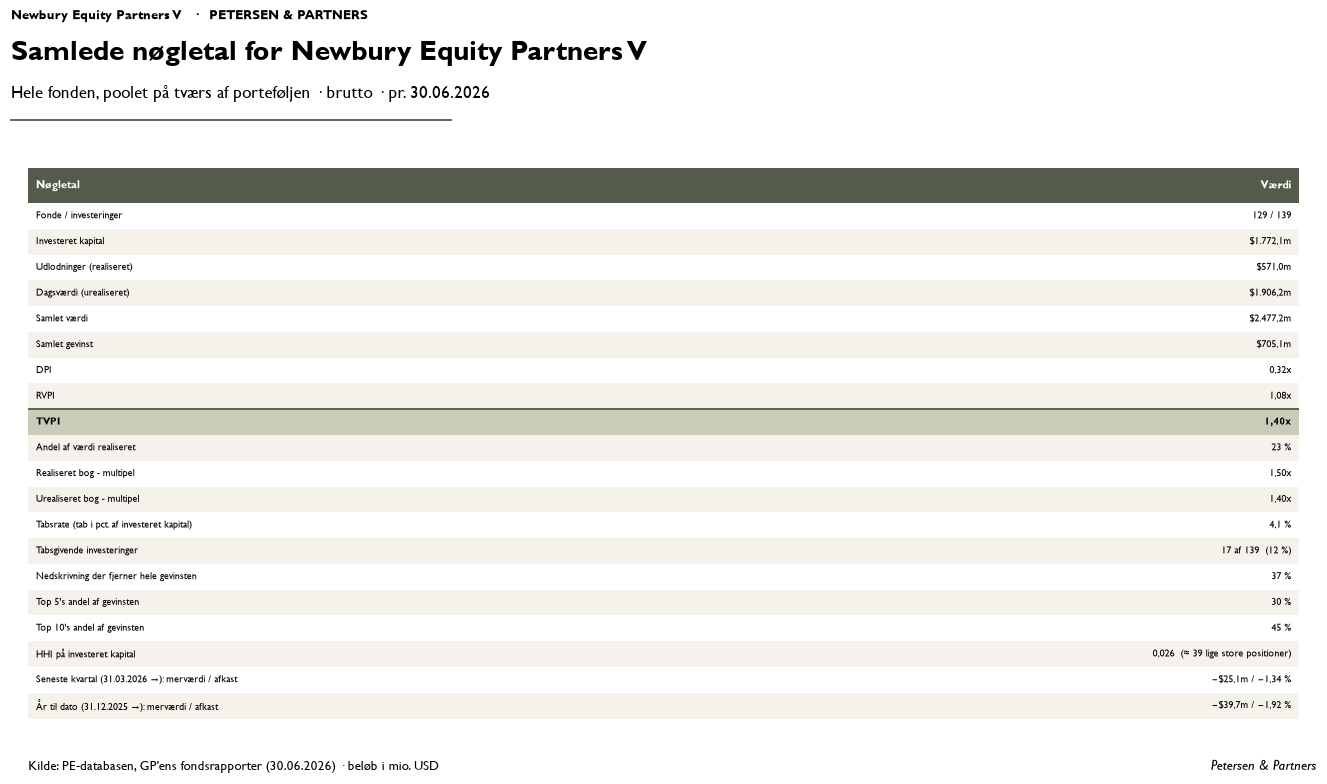

In [35]:
pf.tabel_noegletal()

gemt: charts\nep5_portefoelje_tabel_gruppe.png  (3200 x 1800 px · 16:9)


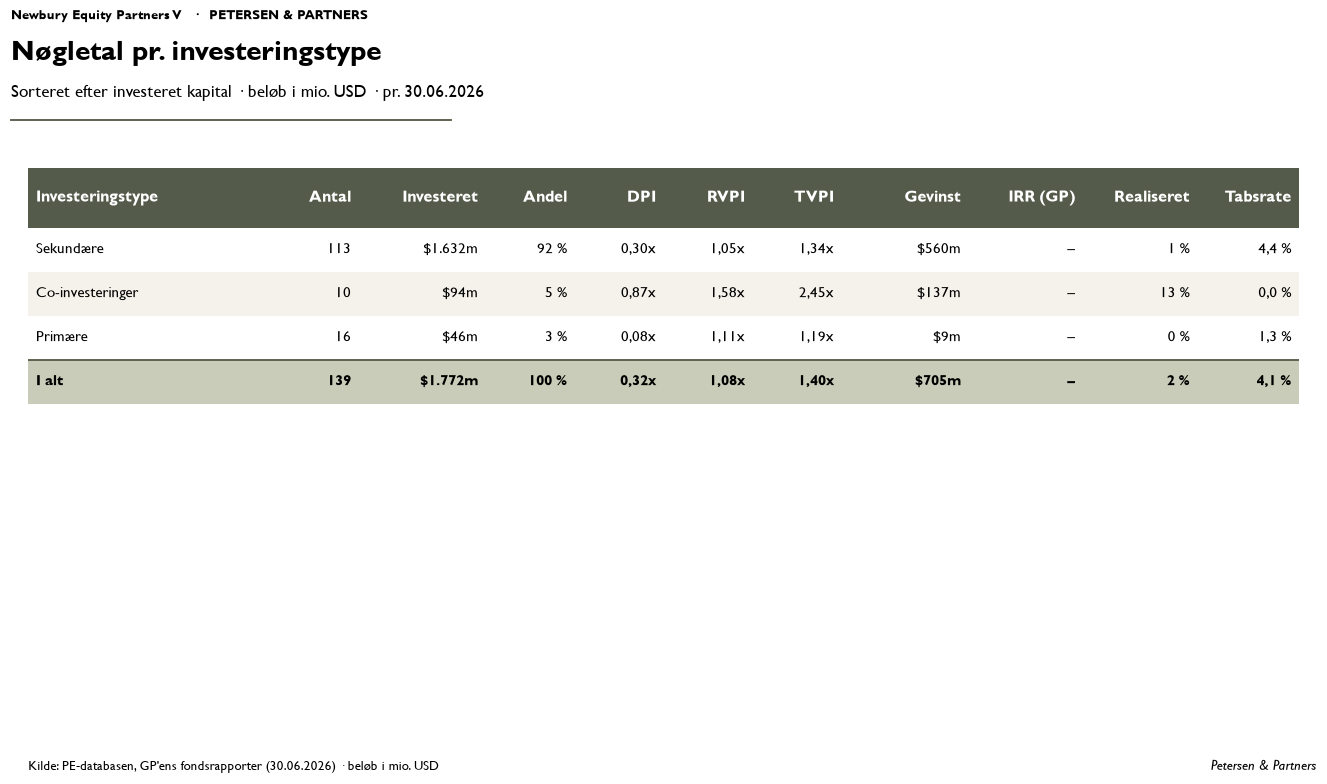

In [36]:
pf.tabel_gruppe()

gemt: charts\nep5_portefoelje_tabel_vintage.png  (3200 x 1800 px · 16:9)


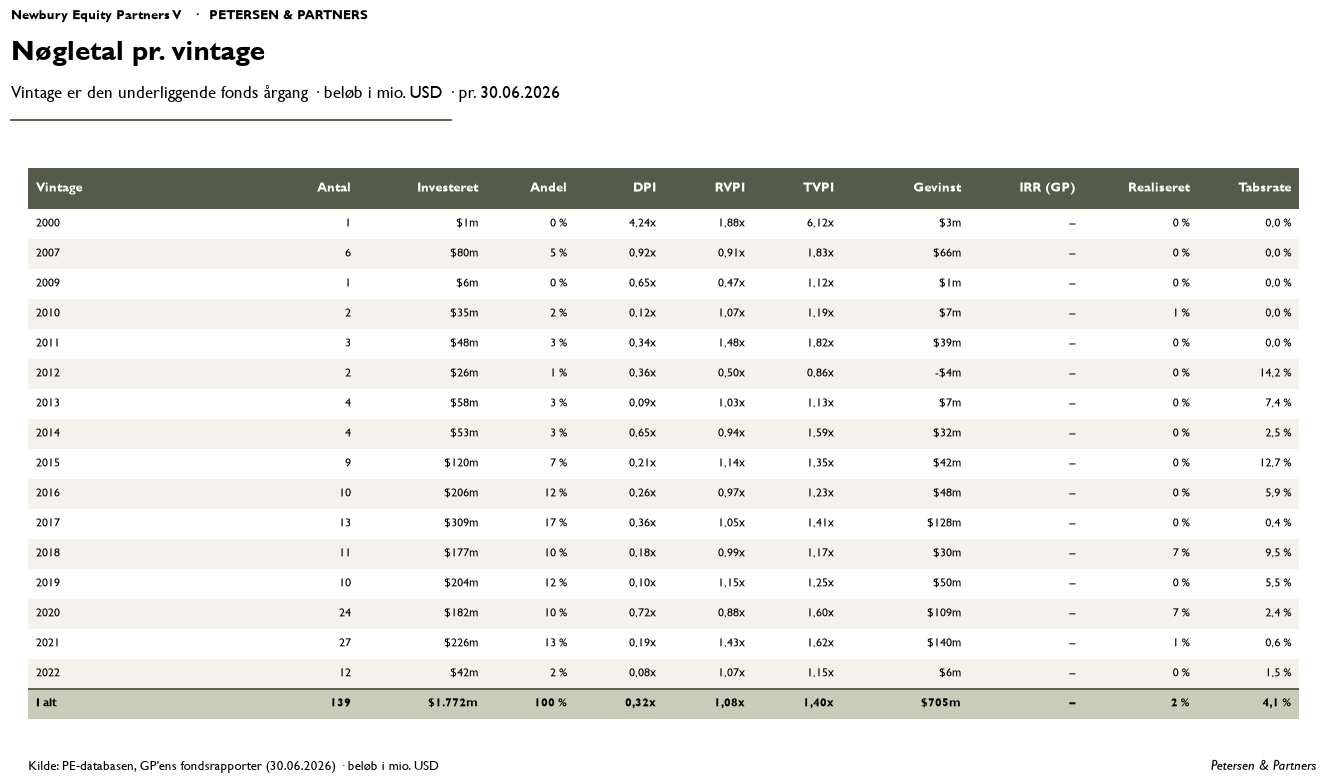

In [37]:
pf.tabel_vintage()

gemt: charts\nep5_portefoelje_tabel_selskaber_side1.png  (3200 x 1800 px · 16:9)


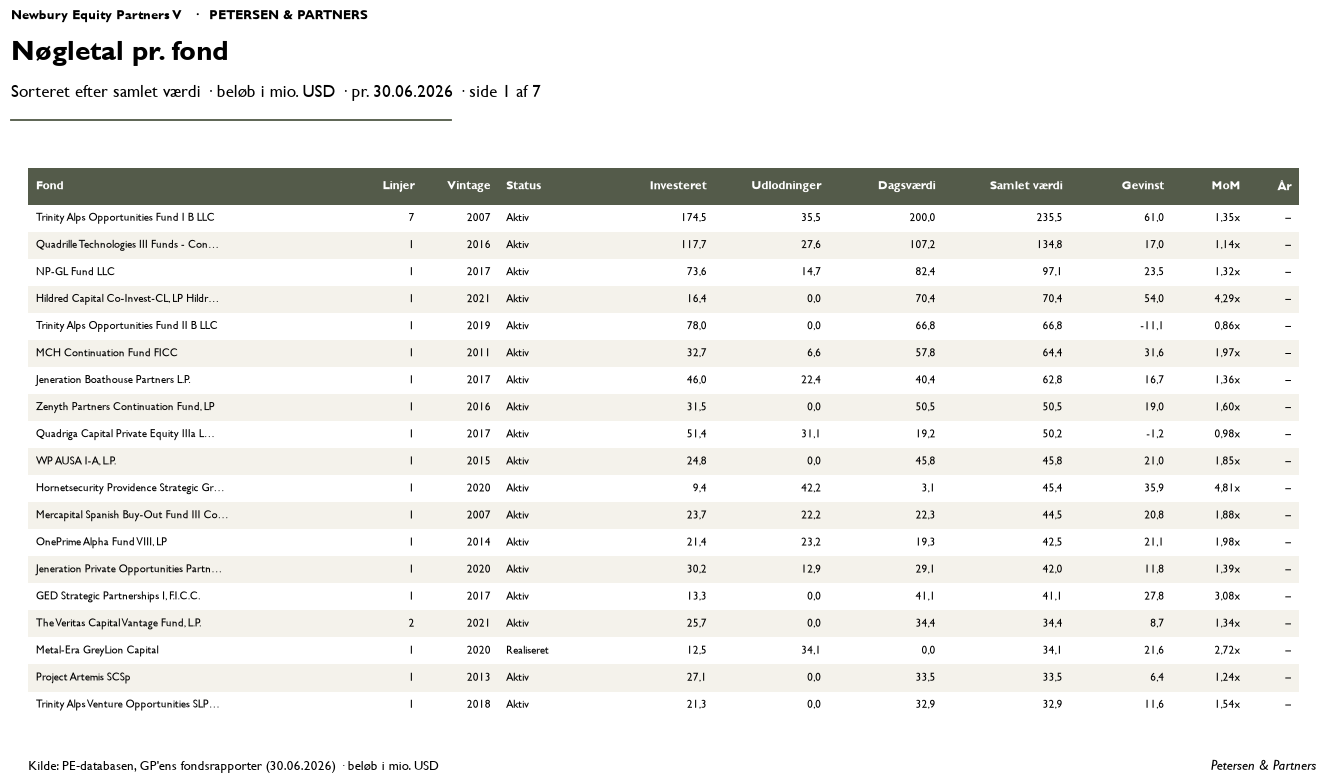

gemt: charts\nep5_portefoelje_tabel_selskaber_side2.png  (3200 x 1800 px · 16:9)


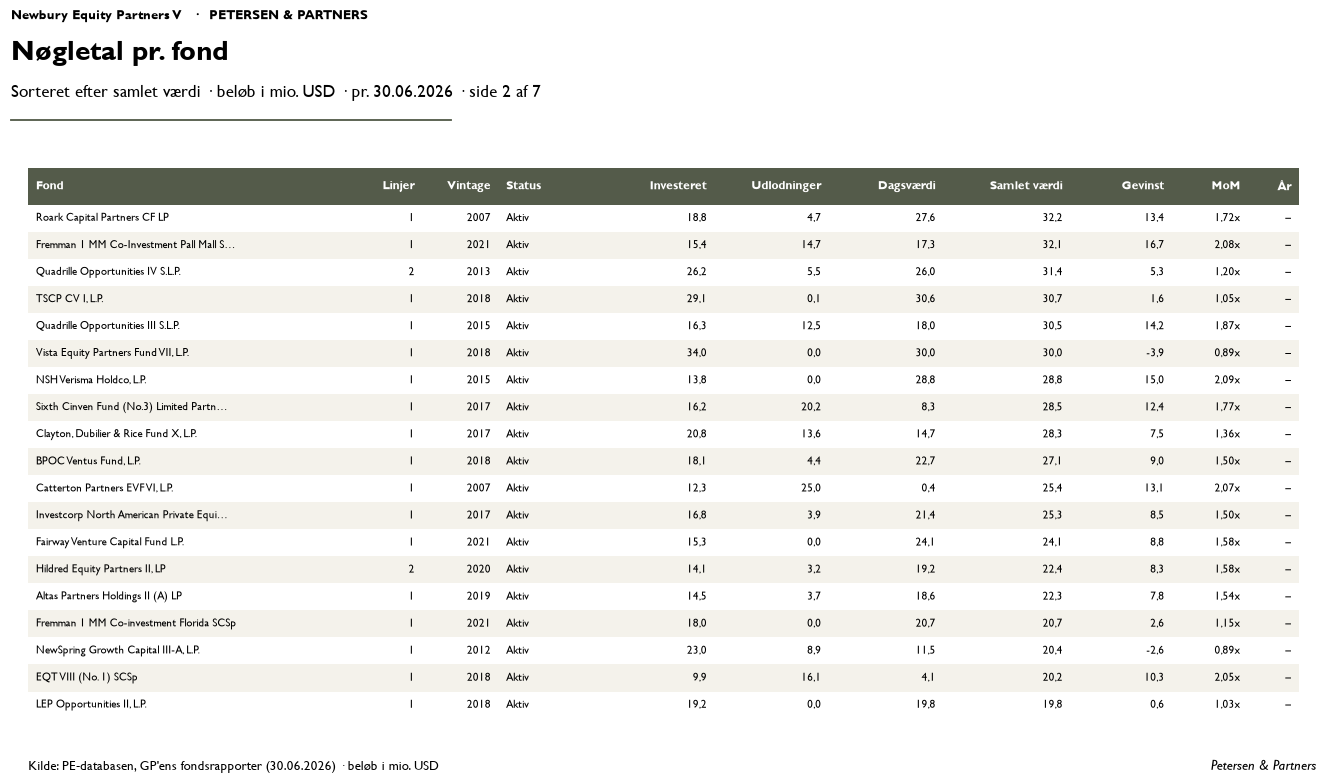

gemt: charts\nep5_portefoelje_tabel_selskaber_side3.png  (3200 x 1800 px · 16:9)


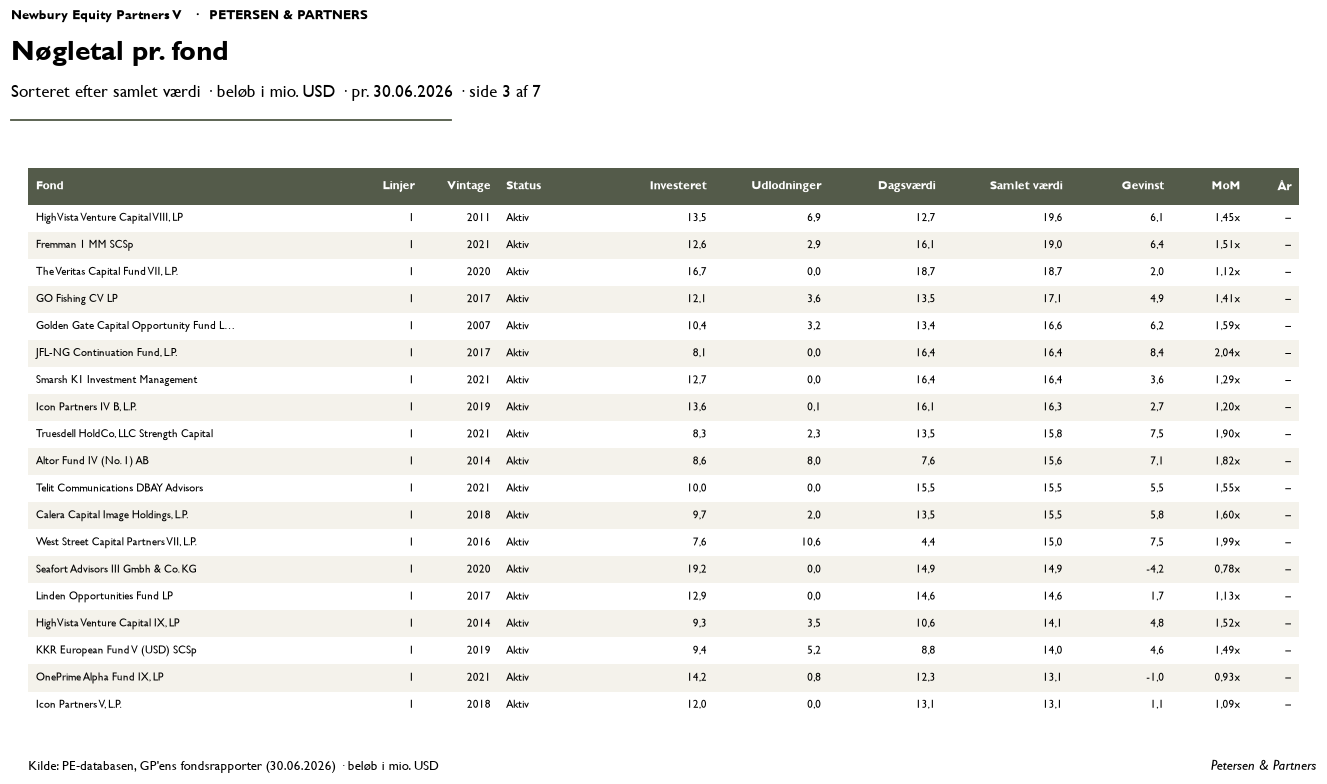

gemt: charts\nep5_portefoelje_tabel_selskaber_side4.png  (3200 x 1800 px · 16:9)


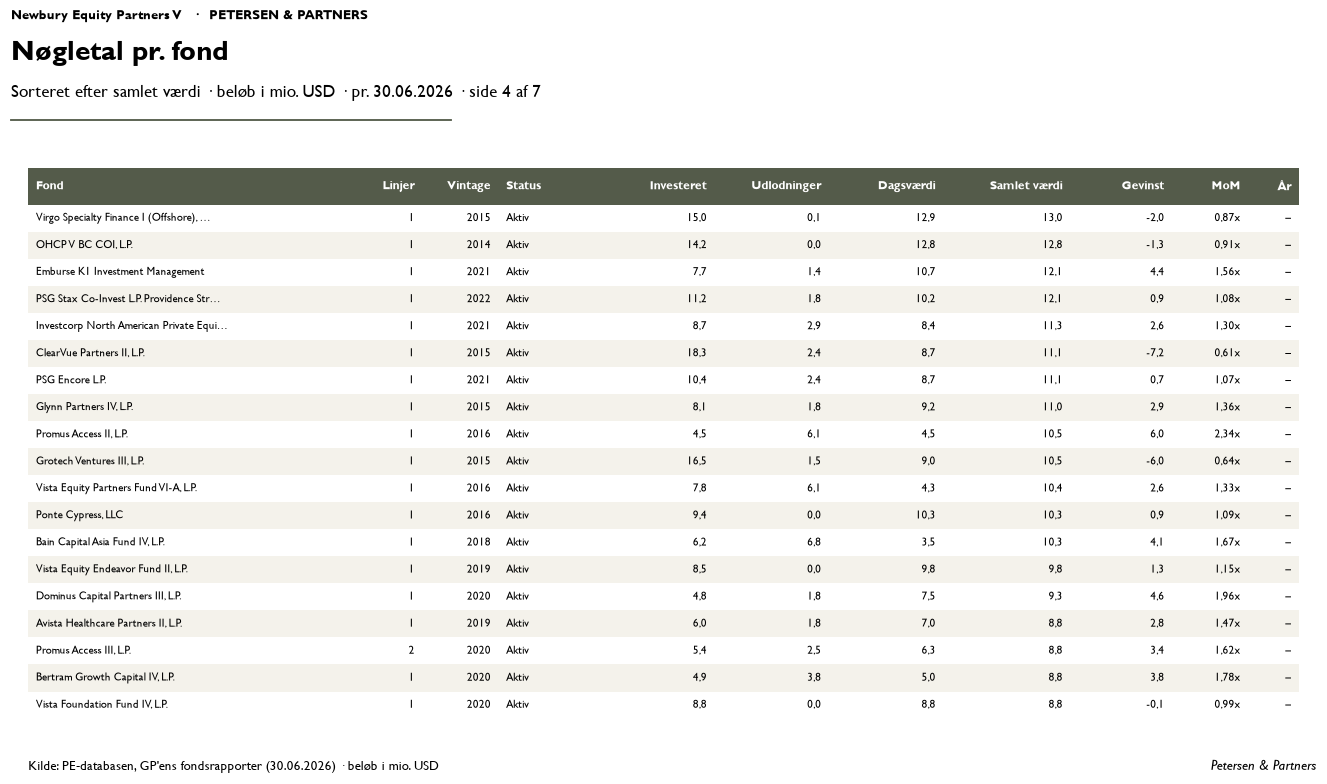

gemt: charts\nep5_portefoelje_tabel_selskaber_side5.png  (3200 x 1800 px · 16:9)


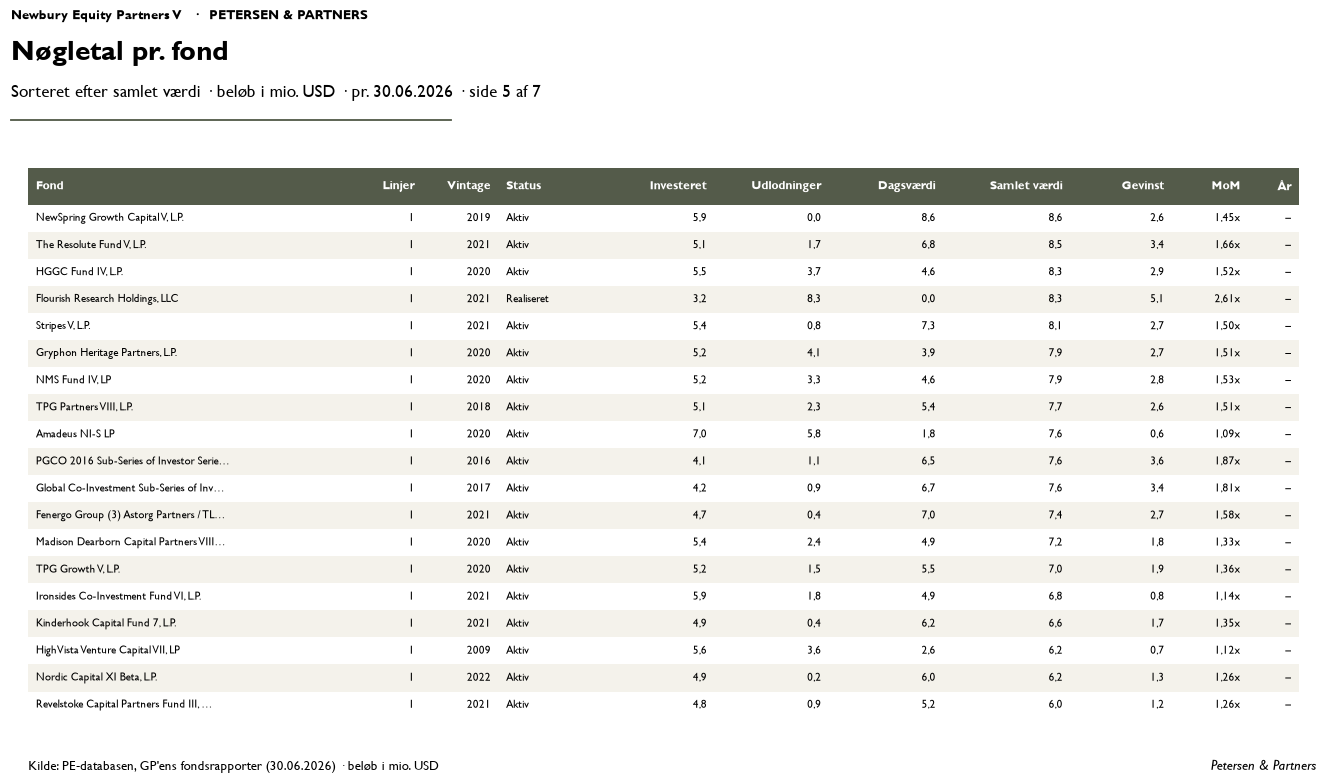

gemt: charts\nep5_portefoelje_tabel_selskaber_side6.png  (3200 x 1800 px · 16:9)


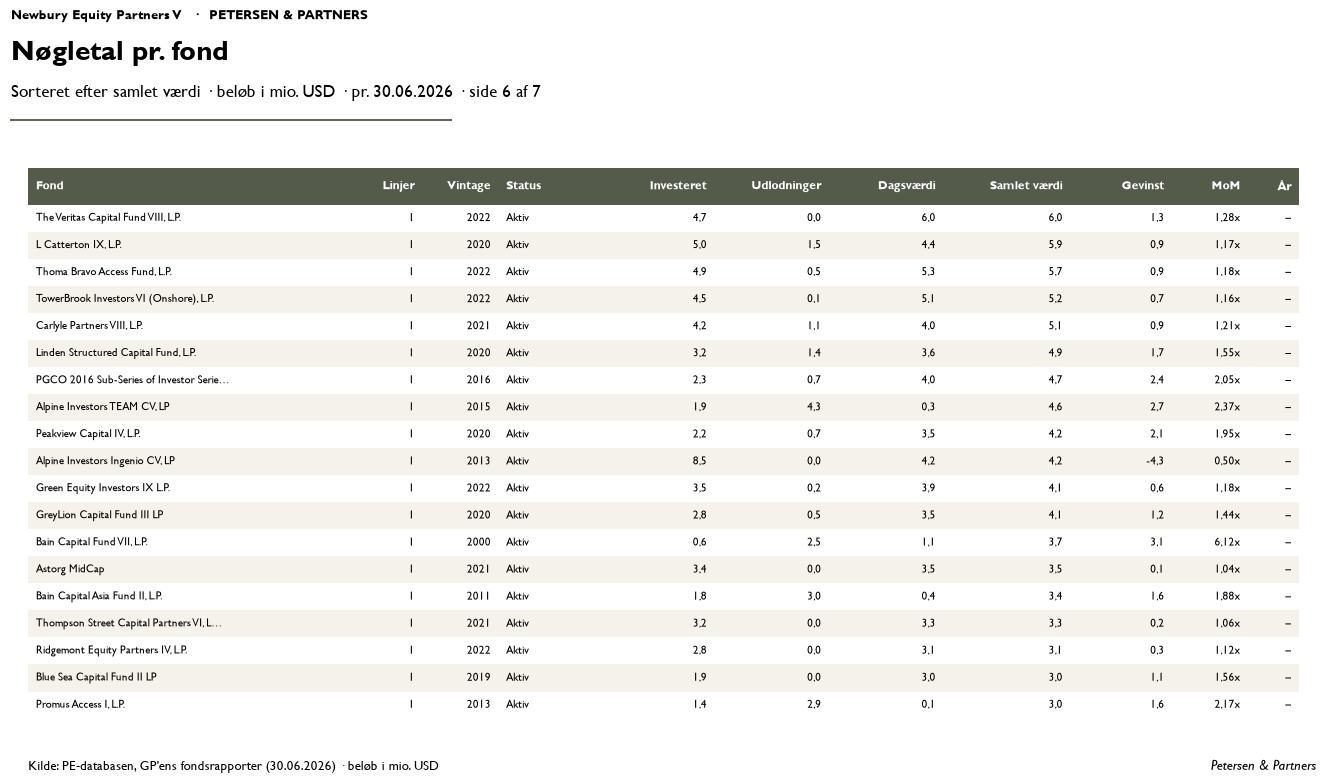

gemt: charts\nep5_portefoelje_tabel_selskaber_side7.png  (3200 x 1800 px · 16:9)


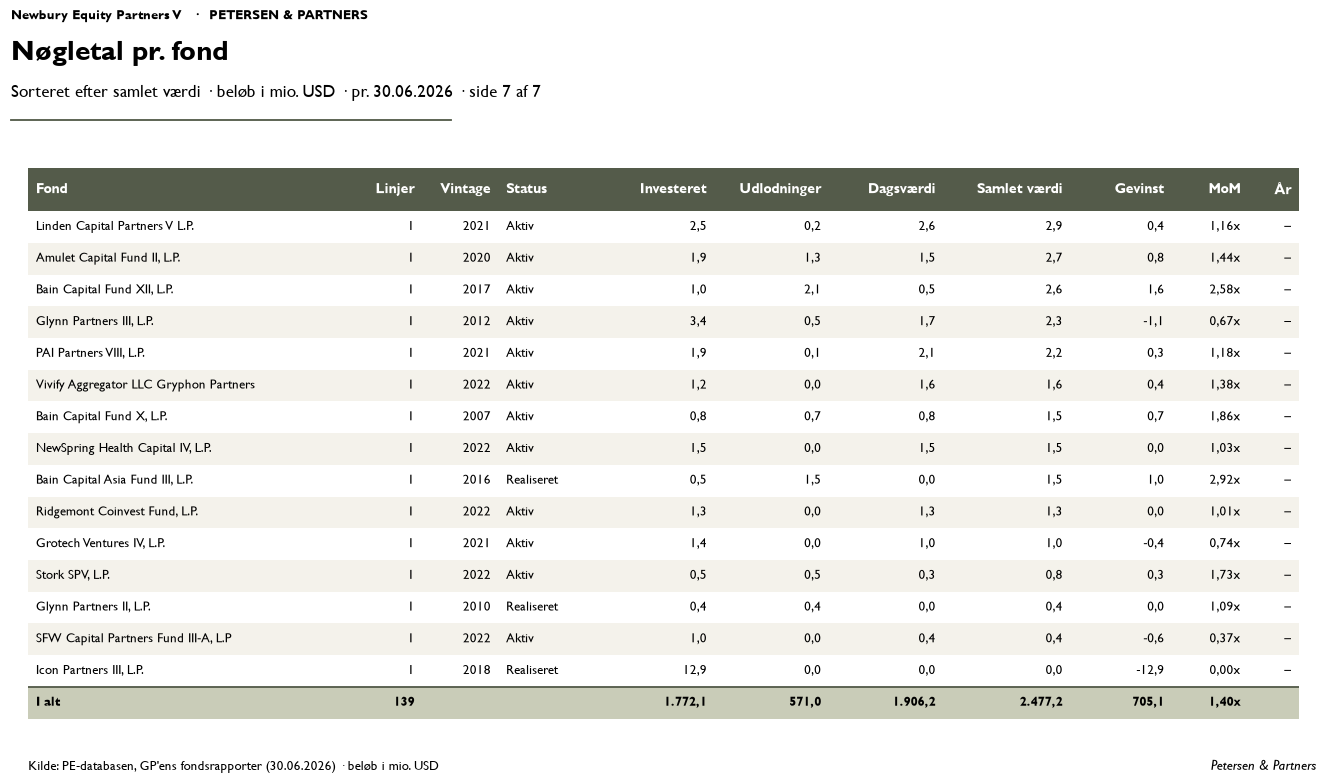

In [38]:
pf.tabel_selskaber()

In [39]:
pf.tabel_positioner()

Ingen positioner pr. tranche over tid for NEP5 - springer over


In [40]:
pf.tabel_delboeger()

Ingen delbøger defineret for fonden for NEP5 - springer over


# Eksport

Excel med alle tabellerne bag graferne, og ét deck på PPIM-masteren.

In [41]:
pf.excel()

gemt: exports\nep5_portefoelje_30062026.xlsx  (10 ark · beløb i mio. USD)


WindowsPath('exports/nep5_portefoelje_30062026.xlsx')

In [42]:
pf.deck()

gemt: exports\nep5_portefoelje_30062026.pptx  (44 slides)


WindowsPath('exports/nep5_portefoelje_30062026.pptx')